In [98]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [99]:
path = r'D:/Universidad/5to Semestre/Inteligencia Artificial/git/Datasets Preparados/D7 Statlog (Australian Credit Approval)/australian_optimized_model.csv '
df = pd.read_csv(path)

X = df.values.astype(np.float32)
y = df['class'].values.astype(np.float32)

In [100]:
print(X)

[[2.208e+01 1.146e+01 2.000e+00 ... 2.000e+00 1.213e+03 0.000e+00]
 [2.267e+01 7.000e+00 2.000e+00 ... 2.000e+00 1.000e+00 0.000e+00]
 [2.958e+01 1.750e+00 1.000e+00 ... 2.000e+00 1.000e+00 0.000e+00]
 ...
 [1.883e+01 9.540e+00 2.000e+00 ... 2.000e+00 1.000e+00 1.000e+00]
 [2.742e+01 1.450e+01 2.000e+00 ... 2.000e+00 1.200e+01 1.000e+00]
 [4.100e+01 4.000e-02 2.000e+00 ... 1.000e+00 1.000e+00 1.000e+00]]


In [101]:
X_train = X[:525]
y_train = y[:525]

X_test = X[525:688]
y_test = y[525:688]

In [102]:
X_mean = X_train.mean(axis=0)
X_std = X_train.std(axis=0)

X_std[X_std == 0] = 1

X_raw = np.nan_to_num(X_train)
X_test_raw = np.nan_to_num(X_test)

X_train = (X_raw - X_mean) / X_std
X_test = (X_test_raw - X_mean) / X_std

In [103]:
class DatasetClasificacion(torch.utils.data.Dataset):

    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32).view(-1,1)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [104]:
train_dataset = DatasetClasificacion(X_train, y_train)
test_dataset = DatasetClasificacion(X_test, y_test)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)

In [105]:
n_entradas = X.shape[1]
model = torch.nn.Sequential(
    torch.nn.Linear(n_entradas, 64),
    torch.nn.ReLU(),
    torch.nn.Dropout(0.3),
    torch.nn.Linear(64, 32),
    torch.nn.ReLU(),
    torch.nn.Linear(32, 1)
)

criterion = torch.nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [106]:
epochs = 300
best_loss = float("inf")

history_accuracy = []
history_loss = []
history_train_acc = []
history_test_acc = []

for epoch in range(epochs):
    model.train()
    epoch_loss_list = []
    train_correct = 0
    train_total = 0

    for X_batch, y_batch in train_loader:
        y_pred = model(X_batch)
        loss = criterion(y_pred, y_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        preds = (torch.sigmoid(y_pred) > 0.5).float()
        train_correct += (preds == y_batch).sum().item()
        train_total += y_batch.size(0)

        epoch_loss_list.append(loss.item())

    model.eval()
    test_correct = 0
    test_total = 0

    with torch.no_grad():
        for X_test_batch, y_test_batch in test_loader:
            y_test_pred = model(X_test_batch)
            preds_test = (torch.sigmoid(y_test_pred) > 0.5).float()
            test_correct += (preds_test == y_test_batch).sum().item()
            test_total += y_test_batch.size(0)

    avg_loss = np.mean(epoch_loss_list)
    acc_train = train_correct / train_total
    acc_test = test_correct / test_total

    history_loss.append(avg_loss)
    history_train_acc.append(acc_train)
    history_test_acc.append(acc_test)

    if avg_loss < best_loss:
        best_loss = avg_loss
        torch.save(model.state_dict(), "mejor_modelo_binario.pt")
        if (epoch + 1) % 50 == 0 or epoch == 0:
            print(f"Época {epoch+1}: Nuevo mejor modelo guardado (Loss: {avg_loss:.4f})")

    if (epoch + 1) % 100 == 0:
        print(f"[Época {epoch+1}/{epochs}] | Loss: {avg_loss:.4f} | Train Acc: {acc_train*100:.2f}% | Test Acc: {acc_test*100:.2f}%")

print("\n✅ Entrenamiento finalizado.")

Época 1: Nuevo mejor modelo guardado (Loss: 0.6726)
[Época 100/300] | Loss: 0.0003 | Train Acc: 100.00% | Test Acc: 100.00%
Época 150: Nuevo mejor modelo guardado (Loss: 0.0001)
[Época 200/300] | Loss: 0.0001 | Train Acc: 100.00% | Test Acc: 100.00%
[Época 300/300] | Loss: 0.0000 | Train Acc: 100.00% | Test Acc: 100.00%

✅ Entrenamiento finalizado.


In [107]:
model.load_state_dict(torch.load("mejor_modelo_binario.pt"))
model.eval()

Sequential(
  (0): Linear(in_features=13, out_features=64, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.3, inplace=False)
  (3): Linear(in_features=64, out_features=32, bias=True)
  (4): ReLU()
  (5): Linear(in_features=32, out_features=1, bias=True)
)

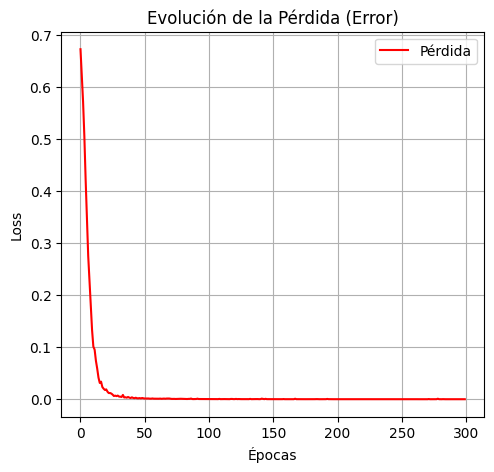

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history_loss, color='red', label='Pérdida')
plt.title('Evolución de la Pérdida (Error)')
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

In [ ]:
precision_train_final = history_train_acc[-1] * 100
precision_test_final = history_test_acc[-1] * 100

print(f"Train Accuracy: {precision_train_final:.2f}%")
print(f"Test Accuracy: {precision_test_final:.2f}%")

Train Accuracy: 100.00%
Test Accuracy: 100.00%


In [110]:
tabla_precision = pd.DataFrame({
    "Tipo de Datos": ["Entrenamiento", "Prueba"],
    "Precisión (%)": [precision_train_final, precision_test_final]
})

print(tabla_precision)

   Tipo de Datos  Precisión (%)
0  Entrenamiento          100.0
1         Prueba          100.0


In [111]:
tabla_precision.style.format({
    "Precisión (%)": "{:.2f}"
})

,Tipo de Datos,Precisión (%)
0,Entrenamiento,100.00
1,Prueba,100.00


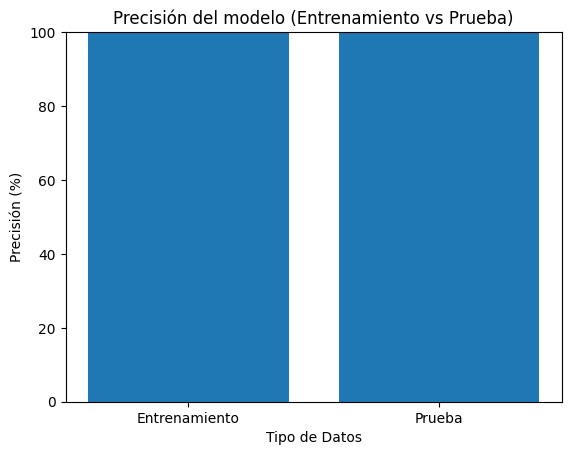

In [112]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(tabla_precision["Tipo de Datos"], tabla_precision["Precisión (%)"])
plt.title("Precisión del modelo (Entrenamiento vs Prueba)")
plt.ylabel("Precisión (%)")
plt.xlabel("Tipo de Datos")
plt.ylim(0, 100)
plt.show()

In [113]:
y_preds = []
y_reales = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        pred = model(X_batch)
        y_preds.append(pred.numpy())
        y_reales.append(y_batch.numpy())

y_preds = np.vstack(y_preds)
y_reales = np.vstack(y_reales)

In [114]:
for i in range(10):
    print(f"Real: {y_reales[i][0]:.2f} | Pred: {torch.sigmoid(torch.tensor(y_preds[i][0])).item():.2f}")

Real: 0.00 | Pred: 0.00
Real: 1.00 | Pred: 1.00
Real: 0.00 | Pred: 0.00
Real: 0.00 | Pred: 0.00
Real: 0.00 | Pred: 0.00
Real: 0.00 | Pred: 0.00
Real: 0.00 | Pred: 0.00
Real: 0.00 | Pred: 0.00
Real: 1.00 | Pred: 1.00
Real: 0.00 | Pred: 0.00
